In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
sys.path.append('../src')

from preprocessing import rename_columns, transform_variables, clean_data, process_status

# ── Tema global ─────────────────────────────────────────────────────────────
PALETTE   = ['#2ecc71', '#e74c3c']          # verde = não default, vermelho = default
PALETTE_C = ['#e74c3c', '#c0392b', '#922b21']  # escala sequencial para default
BG        = '#f9f9f9'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': BG, #Muda o fundo de imagem
    'axes.facecolor':   BG, 
    'axes.spines.top':  False, #Removem as linhas de borda do grafico
    'axes.spines.right':False,
    'figure.dpi':       120, #Aumentar a resolução
})
#Usar para o ticker do matplotlib (funcformatter)
#Se o valor for acima de 1000, será dividido e formatado com k após o valor
def fmt_currency(x, pos):
    """Formata eixo em NT$ milhares."""
    return f'NT${x/1_000:.0f}k' if abs(x) >= 1000 else f'NT${x:.0f}'


| Metrics   | Importance                       |
| --------- | -------------------------------- |
| ROC-AUC   | Class division                   |
| Recall    | Find default                     |
| Precision | Prevent false positives          |
| F1-Score  | Balance                          |
| PR-AUC    | Very useful for unbalance        |


In [18]:
df_raw = pd.read_csv('../data/credit.csv')
#Load do dataset com as transformações das colunas previamente analisadas com drop do id
df = (df_raw
      .pipe(rename_columns)
      .drop(df_raw.index[0])
      .pipe(transform_variables)
      .pipe(clean_data)
      .pipe(process_status))

print(f'Shape após pré-processamento: {df.shape}')
df.head()

Shape após pré-processamento: (30000, 25)


,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
1,1,20000,2,2,1,24,2,2,0,0,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,0,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,0,0,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Visão Geral do Dataset <a id="2-overview"></a>

### Dicionário de variáveis

| Grupo | Variável | Descrição |
|-------|----------|-----------|
| Identificação | `id` | ID único do cliente |
| Perfil | `limit_bal` | Limite de crédito concedido (NT$) |
| Perfil | `sex` | Sexo (1=M, 2=F) |
| Perfil | `education` | Escolaridade (1=pós-grad, 2=universidade, 3=ensino médio, 4=outros) |
| Perfil | `marriage` | Estado civil (1=casado, 2=solteiro, 3=outros) |
| Perfil | `age` | Idade (anos) |
| Status de pgto | `pay_1`…`pay_6` | Meses de atraso em set–abr/2005 (0=em dia, 1–8=meses de atraso) |
| Faturas | `bill_amt1`…`bill_amt6` | Valor da fatura em set–abr/2005 (NT$) |
| Pagamentos | `pay_amt1`…`pay_amt6` | Valor pago em set–abr/2005 (NT$) |
| **Target** | `default` | **1 = inadimplente no mês seguinte, 0 = não** |

> ⚠️ `pay_*` foi recodificado: valores `-2`, `-1` e `0` tratados como `0` (pagamento em dia).  
> `education` 0/5/6 agrupados em `4` (outros). `marriage` 0 mapeado para `3` (outros).


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         30000 non-null  str  
 1   limit_bal  30000 non-null  int64
 2   sex        30000 non-null  int64
 3   education  30000 non-null  int64
 4   marriage   30000 non-null  int64
 5   age        30000 non-null  int64
 6   pay_1      30000 non-null  int64
 7   pay_2      30000 non-null  int64
 8   pay_3      30000 non-null  int64
 9   pay_4      30000 non-null  int64
 10  pay_5      30000 non-null  int64
 11  pay_6      30000 non-null  int64
 12  bill_amt1  30000 non-null  int64
 13  bill_amt2  30000 non-null  int64
 14  bill_amt3  30000 non-null  int64
 15  bill_amt4  30000 non-null  int64
 16  bill_amt5  30000 non-null  int64
 17  bill_amt6  30000 non-null  int64
 18  pay_amt1   30000 non-null  int64
 19  pay_amt2   30000 non-null  int64
 20  pay_amt3   30000 non-null  int64
 21  pay_amt4   30000 non-nu

In [20]:
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
limit_bal,30000.0,167484.3,129747.7,10000.0,50000.0,140000.0,240000.0,1000000.0
sex,30000.0,1.6,0.5,1.0,1.0,2.0,2.0,2.0
education,30000.0,1.8,0.7,1.0,1.0,2.0,2.0,4.0
marriage,30000.0,1.6,0.5,1.0,1.0,2.0,2.0,3.0
age,30000.0,35.5,9.2,21.0,28.0,34.0,41.0,79.0
pay_1,30000.0,0.4,0.8,0.0,0.0,0.0,0.0,8.0
pay_2,30000.0,0.3,0.8,0.0,0.0,0.0,0.0,8.0
pay_3,30000.0,0.3,0.8,0.0,0.0,0.0,0.0,8.0
pay_4,30000.0,0.3,0.8,0.0,0.0,0.0,0.0,8.0
pay_5,30000.0,0.2,0.7,0.0,0.0,0.0,0.0,8.0


## 3. Qualidade dos Dados <a id="3-qualidade"></a>
Verificação de valores nulos e duplicatas.

In [21]:
df.isnull().sum()

id           0
limit_bal    0
sex          0
education    0
marriage     0
age          0
pay_1        0
pay_2        0
pay_3        0
pay_4        0
pay_5        0
pay_6        0
bill_amt1    0
bill_amt2    0
bill_amt3    0
bill_amt4    0
bill_amt5    0
bill_amt6    0
pay_amt1     0
pay_amt2     0
pay_amt3     0
pay_amt4     0
pay_amt5     0
pay_amt6     0
default      0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df[['sex','education','marriage']].describe()

,sex,education,marriage
count,30000.000000,30000.000000,30000.000000
mean,1.603733,1.842267,1.557267
std,0.489129,0.744494,0.521405
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,2.000000,4.000000,3.000000


## 4. Variável Alvo — `default` <a id="4-target"></a>

O dataset é **desbalanceado**: a classe minoritária (inadimplentes) representa ~22% dos registros.  
Isso impacta diretamente a escolha de métricas (PR-AUC > ROC-AUC) e estratégias de treino (SMOTE, class_weight).


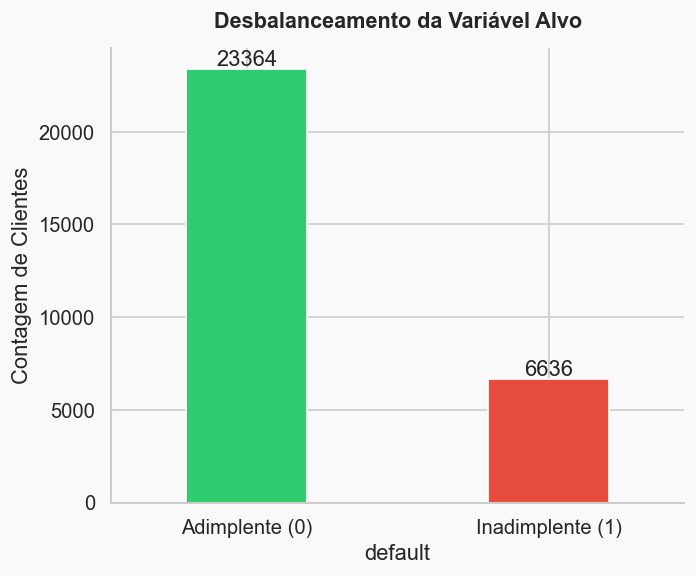

In [24]:
# 1. Cria a figura e plota os dados direto do Pandas
fig, ax = plt.subplots(figsize=(6, 5))
df['default'].value_counts().sort_index().plot(kind='bar', color=PALETTE, width=0.4, ax=ax)

#Adiciona os números em cima das barras
ax.bar_label(ax.containers[0])

#Customização essencial
ax.set_title('Desbalanceamento da Variável Alvo', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'], rotation=0)
ax.set_ylabel('Contagem de Clientes')

plt.tight_layout()
plt.savefig('../plots/target_distribution.png', bbox_inches='tight')
plt.show()

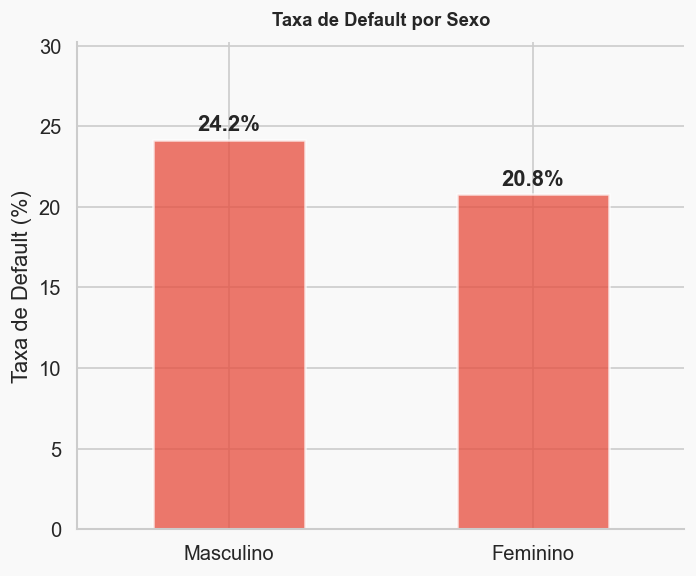

In [25]:
# ── Mapeamentos legíveis ────────────────────────────────────────────────────
df_plot = df.copy()
df_plot['sex_label'] = df_plot['sex'].map({1:'Masculino', 2:'Feminino'})
df_plot['education_label'] = df_plot['education'].map({1:'Pós-Grad', 2:'Universidade', 3:'Ens. Médio', 4:'Outros'})
df_plot['marriage_label']  = df_plot['marriage'].map({1:'Casado', 2:'Solteiro', 3:'Outros'})
df_plot['default_label']   = df_plot['default'].map({0:'Adimplente', 1:'Inadimplente'})


fig, ax = plt.subplots(figsize=(6, 5))
rates_sex = (df_plot.groupby('sex_label')['default'].mean() * 100).reindex(['Masculino', 'Feminino'])

rates_sex.plot(kind='bar', color='#e74c3c', alpha=0.75, edgecolor='white', linewidth=1.5, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold', padding=3)

ax.set_title('Taxa de Default por Sexo', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Taxa de Default (%)')
ax.set_ylim(0, rates_sex.max() * 1.25)
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('')


plt.tight_layout()
plt.savefig('../plots/default_by_sex.png', bbox_inches='tight')
plt.show()

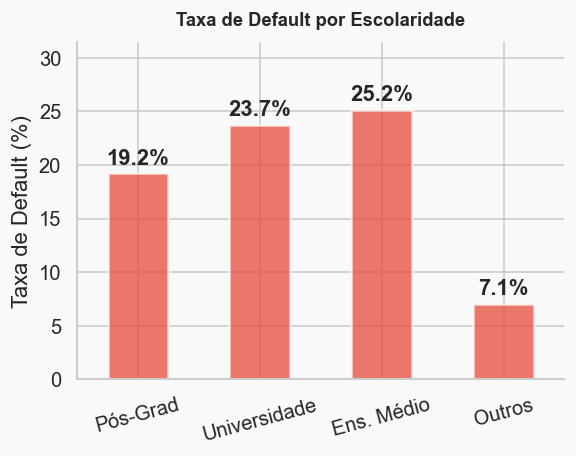

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
rates_edu = (df_plot.groupby('education_label')['default'].mean() * 100).reindex(['Pós-Grad', 'Universidade', 'Ens. Médio', 'Outros'])

rates_edu.plot(kind='bar', color='#e74c3c', alpha=0.75, edgecolor='white', linewidth=1.5, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold', padding=3)

ax.set_title('Taxa de Default por Escolaridade', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Taxa de Default (%)')
ax.set_ylim(0, rates_edu.max() * 1.25)
ax.tick_params(axis='x', rotation=15)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../plots/default_by_education.png', bbox_inches='tight')
plt.show()

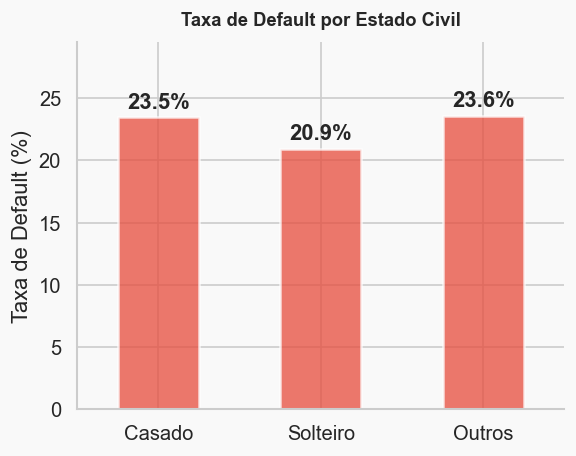

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
rates_mar = (df_plot.groupby('marriage_label')['default'].mean() * 100).reindex(['Casado', 'Solteiro', 'Outros'])

rates_mar.plot(kind='bar', color='#e74c3c', alpha=0.75, edgecolor='white', linewidth=1.5, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold', padding=3)

ax.set_title('Taxa de Default por Estado Civil', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Taxa de Default (%)')
ax.set_ylim(0, rates_mar.max() * 1.25)
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../plots/default_by_marriage.png', bbox_inches='tight')
plt.show()

Adimplente: mediana de idade = 34 anos
Inadimplente: mediana de idade = 34 anos


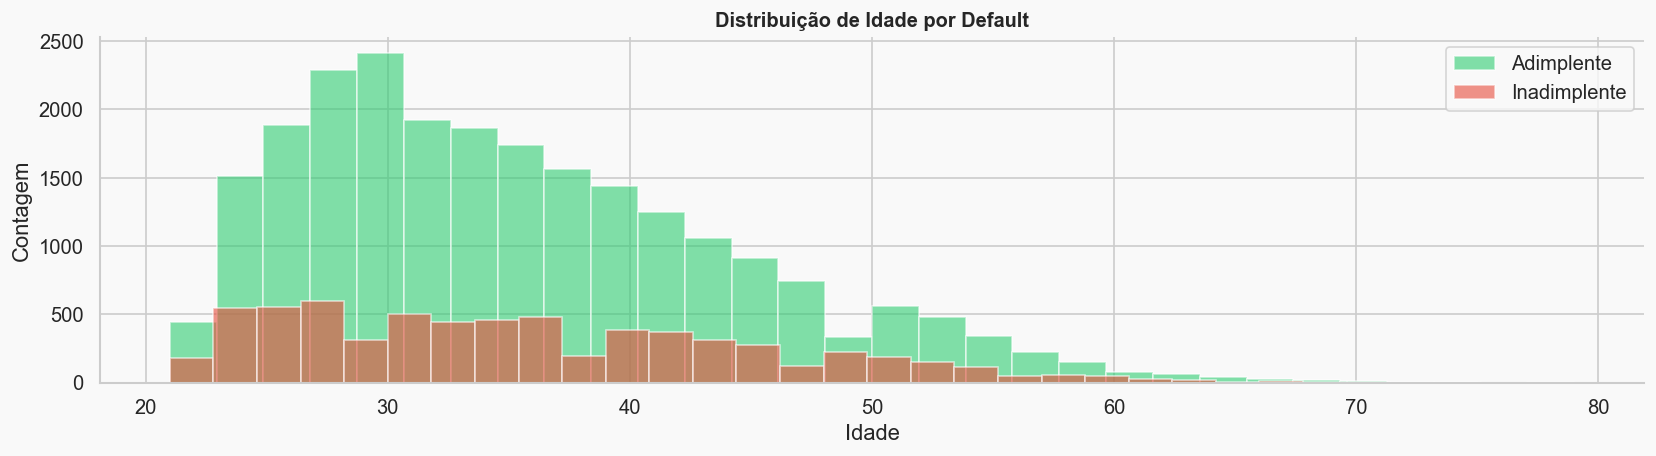

In [28]:
# ── Distribuição de Idade por Default ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Histograma sobreposto
for val, label, color in zip([0, 1], ['Adimplente', 'Inadimplente'], PALETTE):
    subset = df[df['default'] == val]['age']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

ax.set_title('Distribuição de Idade por Default', fontsize=12, fontweight='bold')
ax.set_xlabel('Idade')
ax.set_ylabel('Contagem')
ax.legend()

# Estatísticas
for val, label in zip([0, 1], ['Adimplente', 'Inadimplente']):
    m = df[df['default'] == val]['age'].median()
    print(f'{label}: mediana de idade = {m:.0f} anos')

plt.tight_layout()
plt.savefig('../plots/age_distribution.png', bbox_inches='tight')
plt.show()


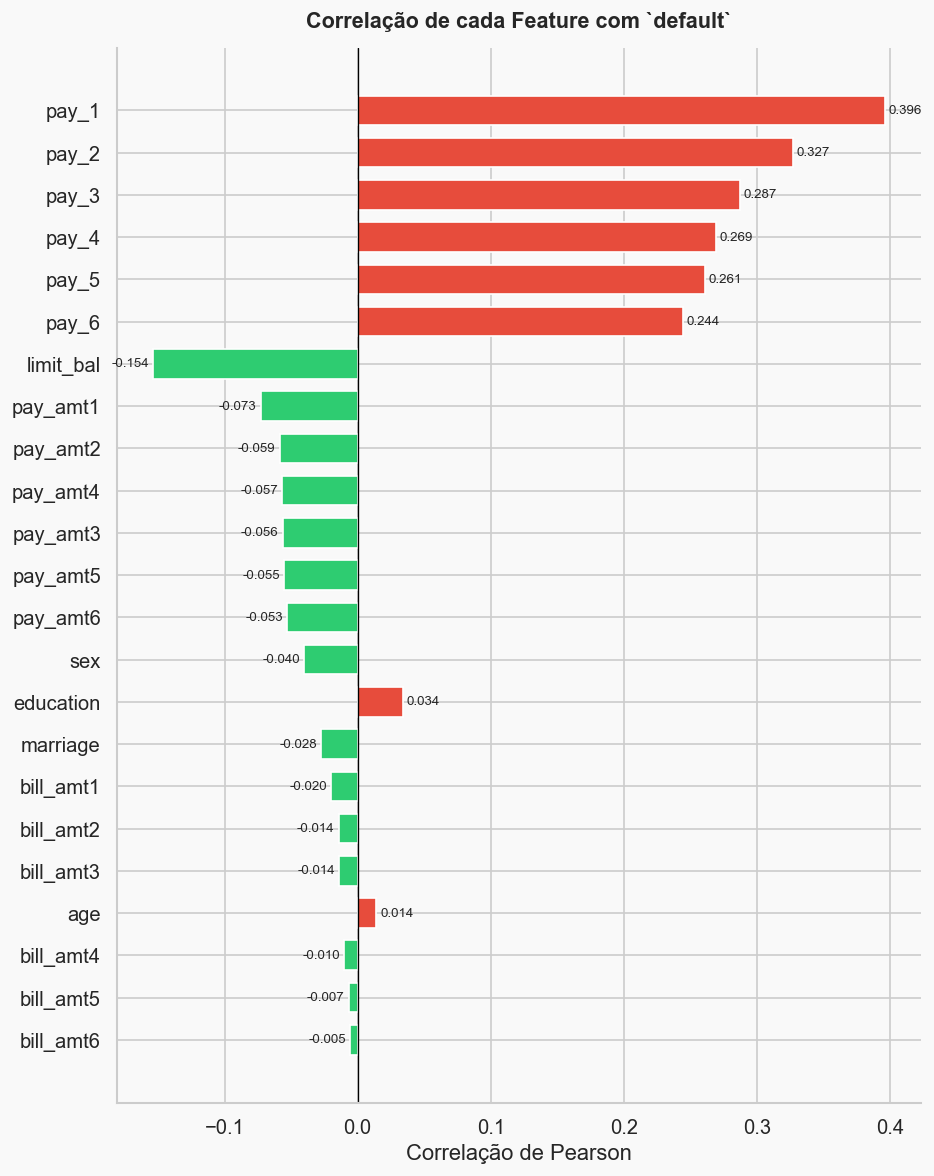

Top 5 features mais correlacionadas com default:
pay_1    0.396019
pay_2    0.327093
pay_3    0.286999
pay_4    0.269055
pay_5    0.260850
Name: default, dtype: float64


In [29]:
df_num = df.drop(columns=['id'], errors='ignore')
corr   = df_num.corr()

# ── 1. Correlação com o target (barras horizontais) ─────────────────────────
target_corr = (corr['default']
               .drop('default')
               .sort_values(key=abs, ascending=False)) #abs transforma em valor absoluto para a leitura de correlação

fig, ax = plt.subplots(figsize=(8, 10))
colors  = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr]
bars    = ax.barh(target_corr.index[::-1], target_corr.values[::-1],
                  color=colors[::-1], edgecolor='white', height=0.7) #[::-1] serve para leitura inversa e estruturar no grafico horizontal

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de cada Feature com `default`',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Correlação de Pearson')

# Valores nas barras
for bar, val in zip(bars, target_corr.values[::-1]): #Junta os as barras(bars) e os valores de correlação(val - target_corr)
    x_pos = bar.get_width() + 0.003 if val >= 0 else bar.get_width() - 0.003 #Define a posição dos valores
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/target_correlation.png', bbox_inches='tight')
plt.show()

print("Top 5 features mais correlacionadas com default:")
print(target_corr.head())


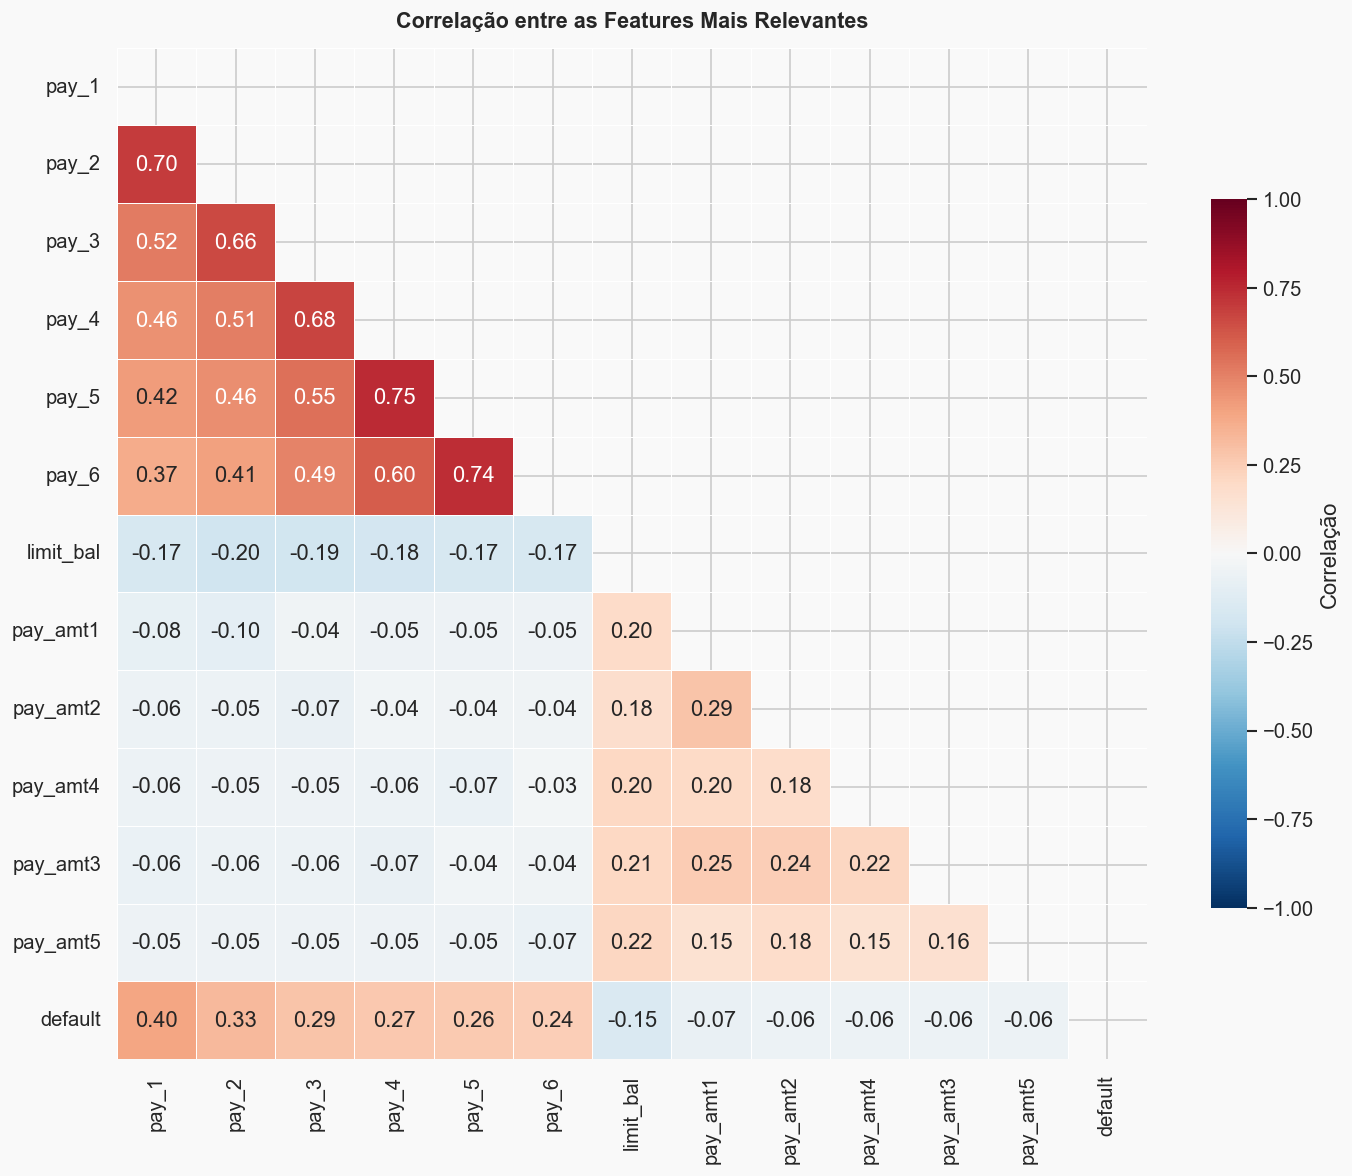

In [30]:
# ── 2. Heatmap de correlação entre features (apenas as mais relevantes) ────
top_features = target_corr.head(12).index.tolist() + ['default']
corr_top     = df_num[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask    = np.triu(np.ones_like(corr_top, dtype=bool))  # mostra só metade inferior

sns.heatmap(corr_top, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlação', 'shrink': 0.7}, ax=ax)

ax.set_title('Correlação entre as Features Mais Relevantes',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('../plots/correlation_heatmap_top.png', bbox_inches='tight')
plt.show()


**Leitura:**
- As variáveis `pay_1` a `pay_6` são as mais correlacionadas com `default` — **comportamento de atraso é o melhor sinal**.
- `limit_bal` tem correlação negativa com default: maior limite → menor risco.


## 10. Conclusões para Modelagem <a id="10-conclusoes"></a>

### 🔍 Findings principais

| Tema | Achado | Impacto na Modelagem |
|------|--------|----------------------|
| **Desbalanceamento** | ~22% de defaults | Usar SMOTE ou `class_weight`; métricas: PR-AUC, Recall |
| **Variáveis de atraso** | `pay_1`–`pay_6` mais correlacionadas com target | Feature importance alta; considerar `n_delays` e `max_delay` |
| **Limite de crédito** | Inadimplentes têm limites menores | `limit_bal` feature relevante; criar `util_ratio` |
| **Faturas** | Alta multicolinearidade entre `bill_amt*` | Agregar em `avg_bill`; criar `pay_ratio` |
| **Perfil demográfico** | Sexo, escolaridade e estado civil têm impacto pequeno | Usar, mas não são os principais preditores |

### 📐 Métricas de avaliação

| Métrica | Por quê usar |
|---------|-------------|
| **PR-AUC** | Melhor para datasets desbalanceados |
| **Recall** | Queremos capturar o máximo de inadimplentes reais |
| **Precision** | Evitar falsos alarmes excessivos |
| **ROC-AUC** | Referência geral de separabilidade |
